---
# TAHAP 1 — Setup & Konfigurasi

In [13]:
import os
import numpy as np
import pandas as pd
import cv2
import sys
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm

# menambahkan module dari berbagai folder
sys.path.append(os.path.abspath(".."))
from preprocessing import resize_images, resize_masks, laplacian_hr, bothat_hr
from dataset import ISICDataset
from torch.utils.data import DataLoader
from utils.augmentation import get_train_transforms, get_val_transforms
import torch

In [8]:
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.append(ROOT)

In [9]:
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATASET_DIR = os.path.join(ROOT, 'dataset')
SPLITS      = ['training', 'validation', 'testing']
EXPERIMENTS = ['original', 'bothat', 'laplacian']

print(f'Device      : {DEVICE}')
print(f'Dataset dir : {DATASET_DIR}')
print('✅ Import berhasil!')

Device      : cuda
Dataset dir : c:\Users\Cerdas05\Skripshot\U-Net-Architecture\dataset
✅ Import berhasil!


# EDA

## Jumlah dan distribusi data

In [11]:
splits = ['training', 'testing', 'validation']

data_count = {}

for split in splits:
    images = Path(DATASET_DIR) / split / 'images'
    masks = Path(DATASET_DIR) / split / 'masks'

    n_images = len(list(images.glob("*"))) if images.exists() else 0
    n_masks = len(list(masks.glob("*"))) if masks.exists() else 0

    data_count[split] = {
        'gambar': n_images,
        'mask': n_masks,
        'Cocok'  : '✅' if n_images == n_masks else '❌'
    }

df_count = pd.DataFrame(data_count).T
df_count.index_name = 'split'

print('\n── Distribusi Jumlah Data ──')
print(df_count.to_string())
print(f'\nTotal gambar: {df_count["gambar"].sum()}')



── Distribusi Jumlah Data ──
           gambar  mask Cocok
training     2595  2595     ✅
testing      1001  1001     ✅
validation    101   101     ✅

Total gambar: 3697


## Distribusi ukuran gambar

In [14]:
img_dir = Path(DATASET_DIR) / 'training' / 'images'
img_paths = sorted(list(img_dir.glob("*.*")))
heights, widths, aspects = [], [], []

for img_path in tqdm(img_paths, desc="membaca distribusi ukuran gambar"):
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)
        aspects.append(w / h)

print(f"\n-- Statistik Ukuran Gambar (Training)")
print(f"Tinggi -> min: {min(heights)} | max: {max(heights)} | rata-rata: {np.mean(heights):.0f}")
print(f"Lebar -> min: {min(widths)} | max: {max(widths)} | rata-rata: {np.mean(widths):.0f}")

membaca distribusi ukuran gambar:   0%|          | 0/2595 [00:00<?, ?it/s]

membaca distribusi ukuran gambar: 100%|██████████| 2595/2595 [05:57<00:00,  7.26it/s]


-- Statistik Ukuran Gambar (Training)
Tinggi -> min: 540 | max: 4499 | rata-rata: 2167
Lebar -> min: 576 | max: 6748 | rata-rata: 3188


## Plot hasil distribusi gambar 

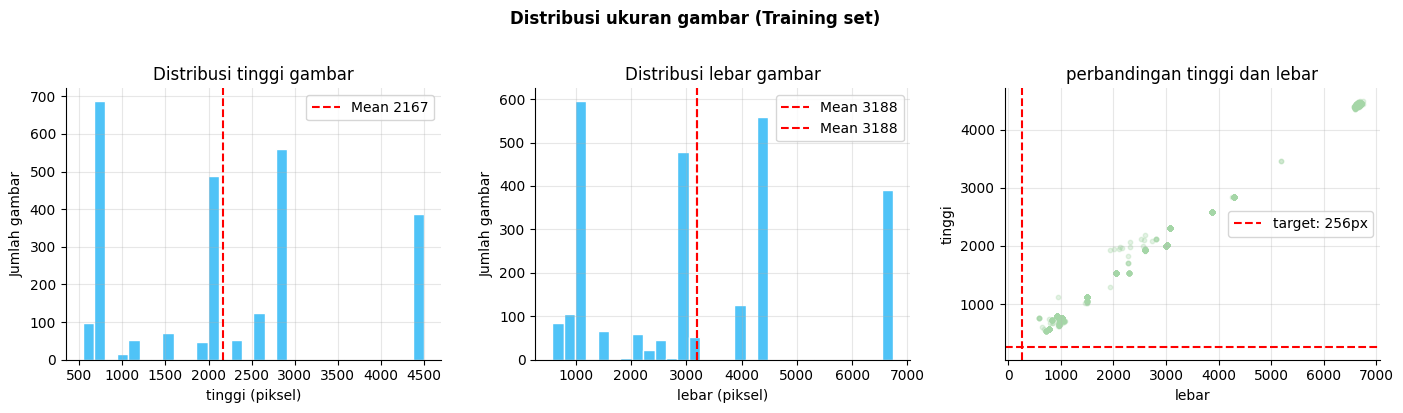

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribusi ukuran gambar (Training set)', fontweight='bold', y=1.02)

axs[0].hist(heights, bins=30, color='#4FC3F7', edgecolor='white')
axs[0].axvline(np.mean(heights), color='red', linestyle='--', linewidth=1.5, label=f'Mean {np.mean(heights):.0f}')
axs[0].set_title('Distribusi tinggi gambar')
axs[0].set_xlabel('tinggi (piksel)')
axs[0].set_ylabel('Jumlah gambar')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].hist(widths, bins=30, color='#4FC3F7', edgecolor='white')
axs[1].axvline(np.mean(widths), color='red', linestyle='--', linewidth=1.5, label=f'Mean {np.mean(widths):.0f}')
axs[1].set_title('Distribusi lebar gambar')
axs[1].set_xlabel('lebar (piksel)')
axs[1].set_ylabel('Jumlah gambar')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[1].hist(widths, bins=30, color='#4FC3F7', edgecolor='white')
axs[1].axvline(np.mean(widths), color='red', linestyle='--', linewidth=1.5, label=f'Mean {np.mean(widths):.0f}')
axs[1].set_title('Distribusi lebar gambar')
axs[1].set_xlabel('lebar (piksel)')
axs[1].set_ylabel('Jumlah gambar')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[2].scatter(widths, heights, alpha=0.3, s=10, color='#A5D6A7')
axs[2].axvline(256, color='red', linestyle='--', linewidth=1.5)
axs[2].axhline(256, color='red', linestyle='--', linewidth=1.5, label='target: 256px')
axs[2].set_title('perbandingan tinggi dan lebar')
axs[2].set_xlabel('lebar')
axs[2].set_ylabel('tinggi')
axs[2].legend()
axs[2].grid(alpha=0.3)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'output/eda/ukuran_distribusi.png'), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
img_path = os.path.join(ROOT, "dataset/training/images/ISIC_0000148.jpg")
image = cv2.imread(img_path)
image_resized = cv2.resize(image, (256, 256),
                           interpolation=cv2.INTER_LANCZOS4)

c:\Users\Cerdas05\anaconda3\envs\torch-pip\lib\site-packages\scipy\signal\_signaltools.py:1673: RuntimeWarning: invalid value encountered in divide
  res *= (1 - noise / lVar)


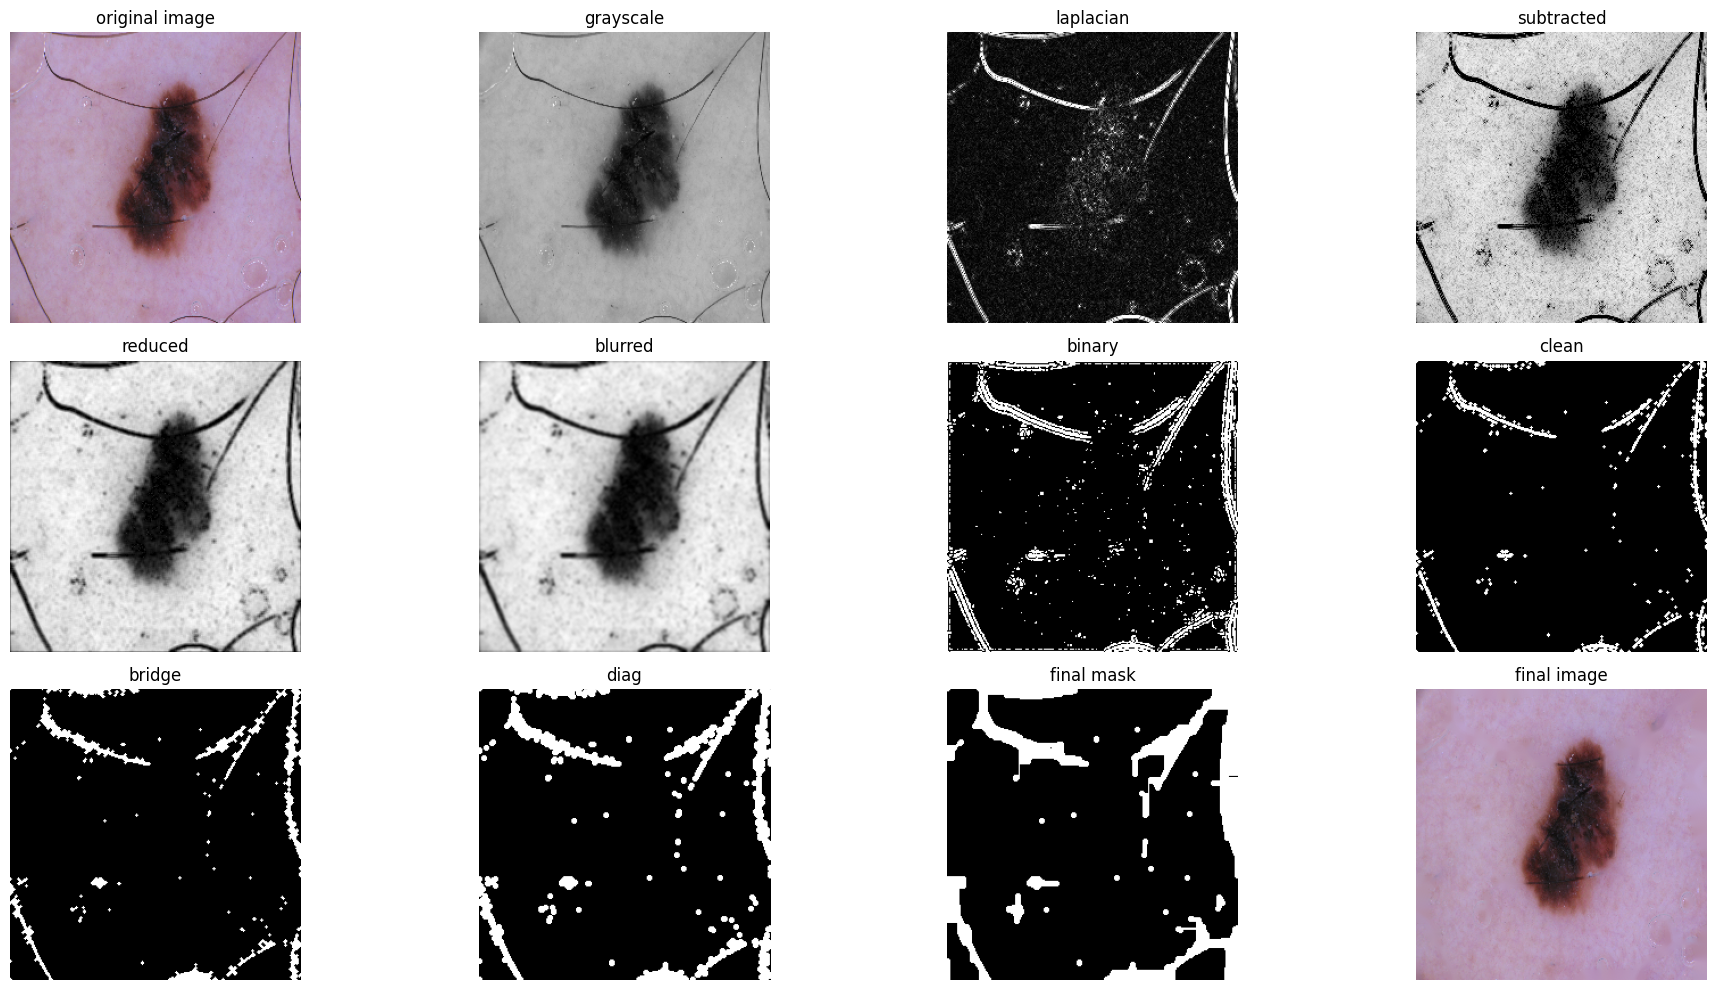

In [17]:
img_laplacian, mask_hair_l = laplacian_hr(image_resized, debug=True)

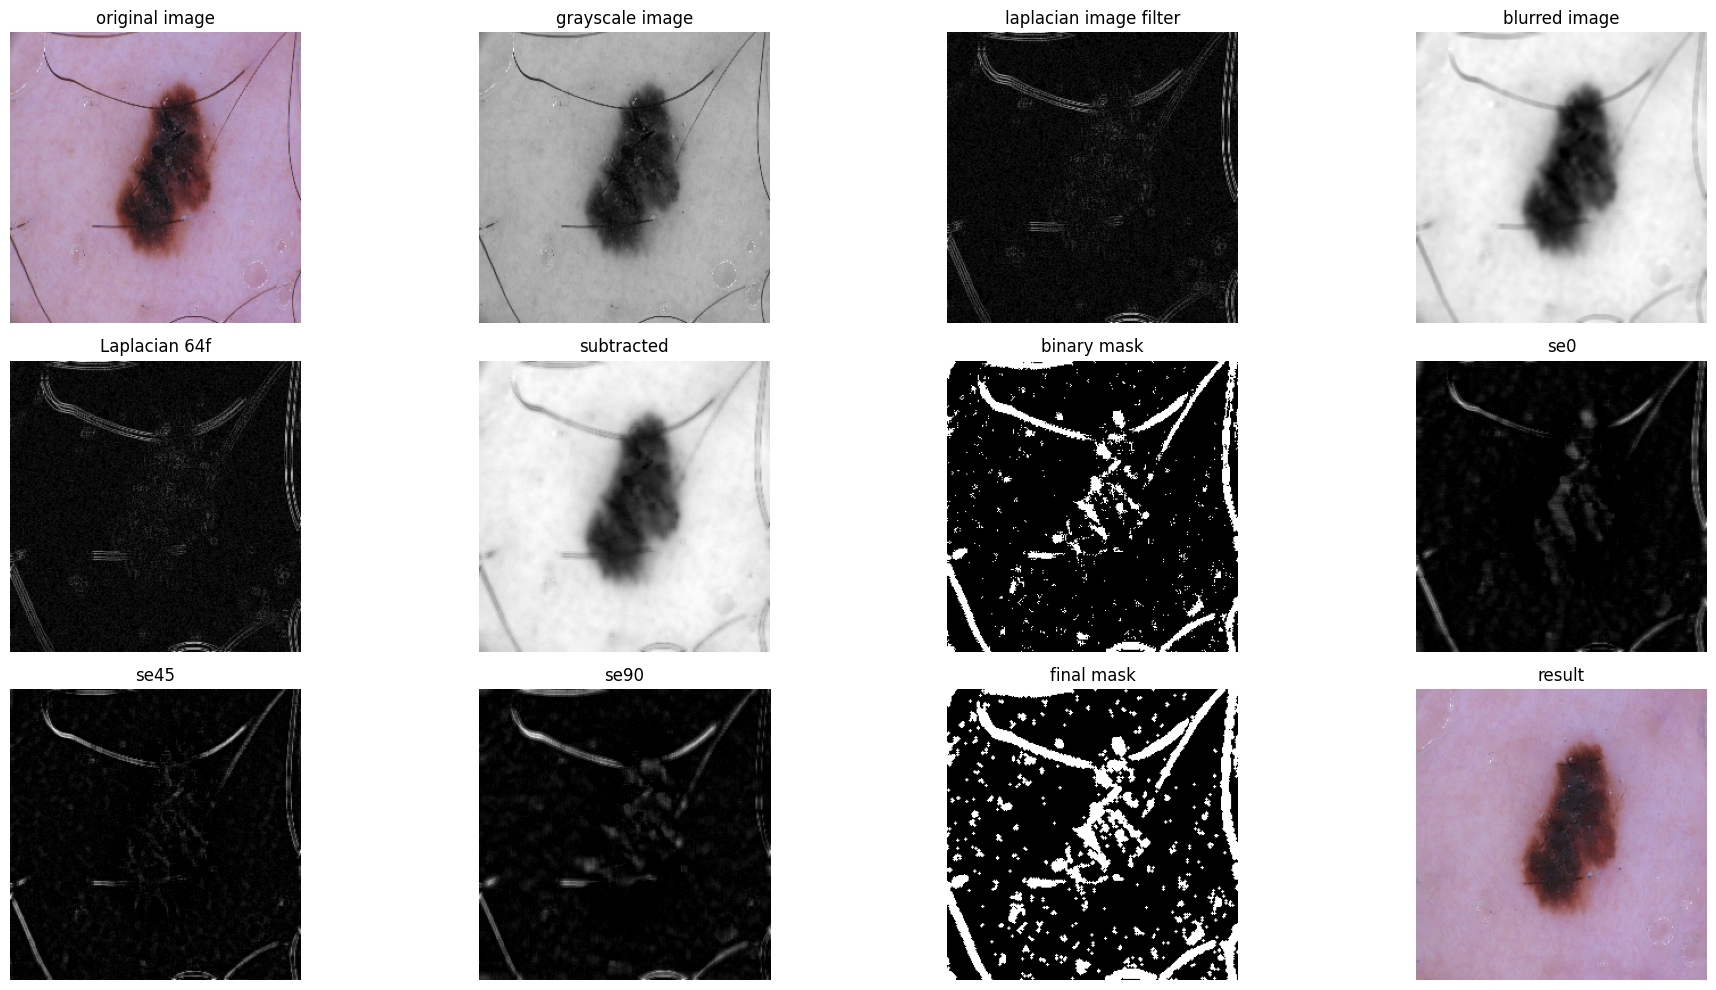

In [11]:
img_bothat, img_mask_b = bothat_hr(image_resized, debug=True)

# Preprocessing

## Resize

In [23]:
print(f"--- mulai resize image dan mask --")

splits = ["training", "testing", "validation"]

for split in splits:
    resize_images(
        input_dir=os.path.join(DATASET_DIR, split, "images"),
        output_dir= os.path.join(ROOT, f"processed/1_resize/{split}/images"),
        size=(256, 256))
    resize_masks(input_dir=os.path.join(DATASET_DIR, split, "images"),
        output_dir= os.path.join(ROOT, f"processed/1_resize/{split}/masks"),
        size=(256, 256))

print("! resize selesai !")


--- mulai resize image dan mask --

  Resize 2594 gambar -> (256, 256)...


    images: 100%|██████████| 2594/2594 [06:33<00:00,  6.60it/s]


    Selesai! gambar berhasil disimpan: c:\Users\Cerdas05\Skripshot\U-Net-Architecture\processed\1_resize\training\images

    Resize 2594 gambar -> (256, 256)...


    images: 100%|██████████| 2594/2594 [07:57<00:00,  5.43it/s]


    Selesai! Disimpan di c:\Users\Cerdas05\Skripshot\U-Net-Architecture\processed\1_resize\training\masks


  Resize 1000 gambar -> (256, 256)...


...

    Selesai! Disimpan di c:\Users\Cerdas05\Skripshot\U-Net-Architecture\processed\1_resize\testing\masks


  Resize 100 gambar -> (256, 256)...


    images: 100%|██████████| 100/100 [00:09<00:00, 10.18it/s]


    Selesai! gambar berhasil disimpan: c:\Users\Cerdas05\Skripshot\U-Net-Architecture\processed\1_resize\validation\images

    Resize 100 gambar -> (256, 256)...


    images: 100%|██████████| 100/100 [00:08<00:00, 11.51it/s]

    Selesai! Disimpan di c:\Users\Cerdas05\Skripshot\U-Net-Architecture\processed\1_resize\validation\masks

! resize selesai !


## Hair removal

In [27]:
from preprocessing import apply_hr

methods = ['laplacian', 'bothat']

apply_hr(method='laplacian',
        input_dir=os.path.join(ROOT, "processed/1_resize/training/images"),
        output_dir=os.path.join(ROOT, "processed/2_laplacian")
         )

apply_hr(method='bothat',
        input_dir=os.path.join(ROOT, "processed/1_resize/training/images"),
        output_dir=os.path.join(ROOT, "processed/2_bothat")
         )

ImportError: cannot import name 'apply_hr' from 'preprocessing' (c:\Users\Cerdas05\Skripshot\U-Net-Architecture\preprocessing\__init__.py)

## Training

In [ ]:
import subprocess

EKSPERIMEN = 'all'   # ← ganti sesuai kebutuhan

print(f'Menjalankan training eksperimen: {EKSPERIMEN}\n')
result = subprocess.run(
    ['python', os.path.join(ROOT, 'train.py'),
     '--experiment', EKSPERIMEN,
     '--epochs', '50'],
    cwd    = ROOT,
    capture_output = False
)

print('\n✅ Training selesai!')